# A/B Testing Experiment

## Two Scenarios

| Scenario | Group A (Control) | Group B (Variant) | Metric |
|---|---|---|---|
| **1. YouTube Thumbnail** | Standard thumbnail | Clickbait thumbnail | Click-Through Rate (CTR) |
| **2. Webpage Design** | Graphic-heavy page | Simplified page | Time Spent (seconds) |

**Each dataset:** 100 users — 50 Control, 50 Variant  
**Test:** Two-sample t-test (α = 0.05, two-tailed)  
**H₀:** No difference between groups | **H₁:** A difference exists


In [1]:
# ── 0. Imports ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
output_dir = os.getcwd()
ALPHA = 0.05
N_PER_GROUP = 50    # 50 control + 50 variant = 100 total

print('Libraries loaded ✓')

Libraries loaded ✓


---
## 📦 Dataset Generation — Both Scenarios

In [2]:
# ── 1. SCENARIO 1 DATASET: YouTube Thumbnail A/B Test ─────────────────────────
#
# Metric  : Click-Through Rate (CTR) per user session — value between 0 and 1
# Control : Standard thumbnail  → lower CTR (mean ≈ 0.30)
# Variant : Clickbait thumbnail → higher CTR (mean ≈ 0.42)
#
# Each row = one unique user who was shown the video on their feed

ctr_control = np.random.beta(a=6,  b=14, size=N_PER_GROUP)   # mean ≈ 0.30
ctr_variant = np.random.beta(a=9,  b=12, size=N_PER_GROUP)   # mean ≈ 0.42

df_youtube = pd.DataFrame({
    'user_id':   np.arange(1, 101),
    'group':     ['Control'] * N_PER_GROUP + ['Variant'] * N_PER_GROUP,
    'thumbnail': ['Standard Thumbnail'] * N_PER_GROUP + ['Clickbait Thumbnail'] * N_PER_GROUP,
    'ctr':       np.round(np.concatenate([ctr_control, ctr_variant]), 4)
})

print('── Scenario 1: YouTube Thumbnail Dataset ──')
print(f'Total rows : {len(df_youtube)}')
print(df_youtube.groupby('group')['ctr'].describe().round(4))
df_youtube.head(6)

── Scenario 1: YouTube Thumbnail Dataset ──
Total rows : 100
         count    mean     std     min     25%     50%     75%     max
group                                                                 
Control   50.0  0.2858  0.0888  0.1404  0.2246  0.2610  0.3466  0.5158
Variant   50.0  0.4356  0.1129  0.2054  0.3616  0.4479  0.4955  0.7320


,user_id,group,thumbnail,ctr
0,1,Control,Standard Thumbnail,0.3450
1,2,Control,Standard Thumbnail,0.2857
2,3,Control,Standard Thumbnail,0.3818
3,4,Control,Standard Thumbnail,0.2266
4,5,Control,Standard Thumbnail,0.4471
5,6,Control,Standard Thumbnail,0.1942


In [3]:
# ── 2. SCENARIO 2 DATASET: Webpage Design A/B Test ────────────────────────────
#
# Metric  : Time spent on page (seconds)
# Control : Graphic-heavy page → longer time  (mean ≈ 180s)
# Variant : Simplified page    → shorter time (mean ≈ 140s)
#
# Each row = one unique visitor session

time_control = np.random.normal(loc=180, scale=35, size=N_PER_GROUP)   # graphic-heavy
time_variant = np.random.normal(loc=140, scale=30, size=N_PER_GROUP)   # simplified

# Clip to realistic range (10s minimum, 400s maximum)
time_control = np.clip(time_control, 10, 400)
time_variant = np.clip(time_variant, 10, 400)

df_webpage = pd.DataFrame({
    'user_id':     np.arange(1, 101),
    'group':       ['Control'] * N_PER_GROUP + ['Variant'] * N_PER_GROUP,
    'page_type':   ['Graphic-Heavy'] * N_PER_GROUP + ['Simplified'] * N_PER_GROUP,
    'time_spent_s': np.round(np.concatenate([time_control, time_variant]), 1)
})

print('── Scenario 2: Webpage Design Dataset ──')
print(f'Total rows : {len(df_webpage)}')
print(df_webpage.groupby('group')['time_spent_s'].describe().round(2))
df_webpage.head(6)

── Scenario 2: Webpage Design Dataset ──
Total rows : 100
         count    mean    std    min     25%     50%     75%    max
group                                                              
Control   50.0  181.96  32.09  105.7  159.20  180.65  197.35  256.6
Variant   50.0  142.69  33.21   78.8  118.62  142.10  171.12  201.8


,user_id,group,page_type,time_spent_s
0,1,Control,Graphic-Heavy,188.6
1,2,Control,Graphic-Heavy,162.3
2,3,Control,Graphic-Heavy,163.5
3,4,Control,Graphic-Heavy,188.1
4,5,Control,Graphic-Heavy,129.3
5,6,Control,Graphic-Heavy,130.7


In [4]:
# ── 3. Save both datasets to CSV ───────────────────────────────────────────────
df_youtube.to_csv(os.path.join(output_dir, 'ab_youtube_dataset.csv'), index=False)
df_webpage.to_csv(os.path.join(output_dir, 'ab_webpage_dataset.csv'), index=False)
print('Datasets saved ✓')
print('  • ab_youtube_dataset.csv')
print('  • ab_webpage_dataset.csv')

Datasets saved ✓
  • ab_youtube_dataset.csv
  • ab_webpage_dataset.csv


---
## 🎬 Scenario 1 — YouTube Thumbnail A/B Test
**Question:** Does a clickbait thumbnail get significantly more clicks than a standard one?

- **Control (A):** Standard Thumbnail
- **Variant (B):** Clickbait Thumbnail
- **Metric:** Click-Through Rate (CTR)

In [5]:
# ── 4. Split groups ────────────────────────────────────────────────────────────
yt_control = df_youtube[df_youtube['group'] == 'Control']['ctr']
yt_variant = df_youtube[df_youtube['group'] == 'Variant']['ctr']

print('Group Summary')
print(f"  Control (Standard)  → mean CTR = {yt_control.mean():.4f} | std = {yt_control.std():.4f}")
print(f"  Variant (Clickbait) → mean CTR = {yt_variant.mean():.4f} | std = {yt_variant.std():.4f}")
print(f"  Observed lift       = {((yt_variant.mean() - yt_control.mean()) / yt_control.mean() * 100):.1f}%")

Group Summary
  Control (Standard)  → mean CTR = 0.2858 | std = 0.0888
  Variant (Clickbait) → mean CTR = 0.4356 | std = 0.1129
  Observed lift       = 52.4%


In [6]:
# ── 5. Welch's Two-Sample T-Test ───────────────────────────────────────────────
t_stat, p_val = stats.ttest_ind(yt_variant, yt_control, equal_var=False)
df_deg = len(yt_control) + len(yt_variant) - 2
pooled_std = np.sqrt((yt_control.std()**2 + yt_variant.std()**2) / 2)
cohens_d = (yt_variant.mean() - yt_control.mean()) / pooled_std

print('='*55)
print('  A/B TEST RESULT — YouTube Thumbnail CTR')
print('='*55)
print(f'  H₀ : CTR_control = CTR_variant  (no difference)')
print(f'  H₁ : CTR_control ≠ CTR_variant  (two-tailed)')
print(f'  Significance level α = {ALPHA}')
print('-'*55)
print(f'  t-statistic : {t_stat:.4f}')
print(f'  p-value     : {p_val:.4f}')
print(f"  Cohen's d   : {cohens_d:.4f}  ({'small' if abs(cohens_d)<0.5 else 'medium' if abs(cohens_d)<0.8 else 'large'} effect)")
print('-'*55)
if p_val < ALPHA:
    print(f'  REJECT H₀  →  Statistically significant difference')
    print(f'  Clickbait thumbnail drives meaningfully more clicks.')
else:
    print(f'  FAIL TO REJECT H₀  →  No significant difference')
    print(f'  Cannot conclude one thumbnail is better.')
print('='*55)

  A/B TEST RESULT — YouTube Thumbnail CTR
  H₀ : CTR_control = CTR_variant  (no difference)
  H₁ : CTR_control ≠ CTR_variant  (two-tailed)
  Significance level α = 0.05
-------------------------------------------------------
  t-statistic : 7.3720
  p-value     : 0.0000
  Cohen's d   : 1.4744  (large effect)
-------------------------------------------------------
  REJECT H₀  →  Statistically significant difference
  Clickbait thumbnail drives meaningfully more clicks.


In [7]:
# ── 6. Confidence Interval for the difference ──────────────────────────────────
diff_mean = yt_variant.mean() - yt_control.mean()
se_diff   = np.sqrt(yt_control.var(ddof=1)/len(yt_control) + yt_variant.var(ddof=1)/len(yt_variant))
t_crit    = stats.t.ppf(1 - ALPHA/2, df=df_deg)
ci_low    = diff_mean - t_crit * se_diff
ci_high   = diff_mean + t_crit * se_diff

print(f'Mean CTR difference (Variant − Control) : {diff_mean:+.4f}')
print(f'95% Confidence Interval : [{ci_low:.4f},  {ci_high:.4f}]')
if ci_low > 0:
    print('→ CI entirely above 0: variant is conclusively better.')
elif ci_high < 0:
    print('→ CI entirely below 0: control is conclusively better.')
else:
    print('→ CI crosses 0: difference is not conclusive.')

Mean CTR difference (Variant − Control) : +0.1498
95% Confidence Interval : [0.1095,  0.1901]
→ CI entirely above 0: variant is conclusively better.


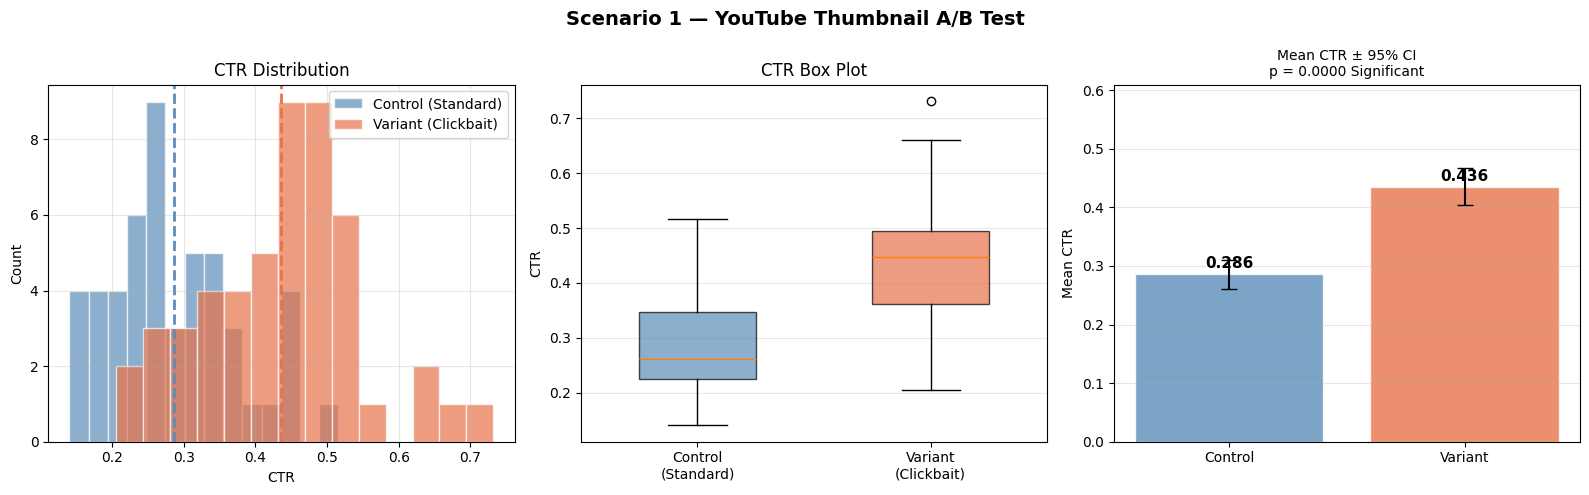

Plot saved ✓


In [8]:
# ── 7. Visualisations — Scenario 1 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Scenario 1 — YouTube Thumbnail A/B Test', fontsize=14, fontweight='bold')

colors = {'Control': '#5B8DB8', 'Variant': '#E8734A'}

# Plot 1: Histogram of CTR distributions
ax = axes[0]
ax.hist(yt_control, bins=14, alpha=0.7, color=colors['Control'], label='Control (Standard)', edgecolor='white')
ax.hist(yt_variant, bins=14, alpha=0.7, color=colors['Variant'], label='Variant (Clickbait)', edgecolor='white')
ax.axvline(yt_control.mean(), color=colors['Control'], lw=2, ls='--')
ax.axvline(yt_variant.mean(), color=colors['Variant'], lw=2, ls='--')
ax.set_title('CTR Distribution'); ax.set_xlabel('CTR'); ax.set_ylabel('Count')
ax.legend(); ax.grid(alpha=0.3)

# Plot 2: Box plot
ax2 = axes[1]
bp = ax2.boxplot([yt_control, yt_variant], labels=['Control\n(Standard)', 'Variant\n(Clickbait)'],
                 patch_artist=True, widths=0.5, notch=False)
bp['boxes'][0].set_facecolor(colors['Control'])
bp['boxes'][1].set_facecolor(colors['Variant'])
for patch in bp['boxes']: patch.set_alpha(0.7)
ax2.set_title('CTR Box Plot'); ax2.set_ylabel('CTR'); ax2.grid(alpha=0.3, axis='y')

# Plot 3: Mean CTR with 95% CI error bars
ax3 = axes[2]
means  = [yt_control.mean(), yt_variant.mean()]
errors = [stats.sem(yt_control) * t_crit, stats.sem(yt_variant) * t_crit]
bars = ax3.bar(['Control', 'Variant'], means, yerr=errors, capsize=6,
               color=[colors['Control'], colors['Variant']], alpha=0.8, edgecolor='white')
ax3.set_title('Mean CTR ± 95% CI'); ax3.set_ylabel('Mean CTR')
ax3.set_ylim(0, max(means) * 1.4)
for bar, mean in zip(bars, means):
    ax3.text(bar.get_x() + bar.get_width()/2, mean + 0.01, f'{mean:.3f}',
             ha='center', fontweight='bold', fontsize=11)
sig_label = f'p = {p_val:.4f} Significant' if p_val < ALPHA else f'p = {p_val:.4f} Not Significant'
ax3.set_title(f'Mean CTR ± 95% CI\n{sig_label}', fontsize=10)
ax3.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'ab_youtube_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✓')

In [9]:
# ── 8. Results Summary Table — Scenario 1 ─────────────────────────────────────
summary_yt = pd.DataFrame({
    'Metric':  ['N', 'Mean CTR', 'Std Dev', 'Std Error', 'Min', 'Max'],
    'Control (Standard)':  [
        len(yt_control),
        round(yt_control.mean(), 4),
        round(yt_control.std(), 4),
        round(stats.sem(yt_control), 4),
        round(yt_control.min(), 4),
        round(yt_control.max(), 4)
    ],
    'Variant (Clickbait)': [
        len(yt_variant),
        round(yt_variant.mean(), 4),
        round(yt_variant.std(), 4),
        round(stats.sem(yt_variant), 4),
        round(yt_variant.min(), 4),
        round(yt_variant.max(), 4)
    ]
})

test_row = pd.DataFrame([{
    'Metric': '── Test Result ──',
    'Control (Standard)': f't = {t_stat:.4f}',
    'Variant (Clickbait)': f'p = {p_val:.4f}'
}])
decision_row = pd.DataFrame([{
    'Metric': 'Decision',
    'Control (Standard)': 'Reject H₀' if p_val < ALPHA else 'Do not reject H₀',
    'Variant (Clickbait)': 'Significant' if p_val < ALPHA else 'Not Significant'
}])
summary_yt = pd.concat([summary_yt, test_row, decision_row], ignore_index=True)

def style_summary(df):
    return (df.style
        .set_properties(**{'text-align': 'center', 'padding': '6px 14px', 'border': '1px solid #ddd'})
        .set_table_styles([{
            'selector': 'th',
            'props': 'background-color:#2c3e50; color:white; text-align:center; padding:8px;'
        }])
    )

style_summary(summary_yt)

,Metric,Control (Standard),Variant (Clickbait)
0,N,50.000000,50.000000
1,Mean CTR,0.285800,0.435600
2,Std Dev,0.088800,0.112900
3,Std Error,0.012600,0.016000
4,Min,0.140400,0.205400
5,Max,0.515800,0.732000
6,── Test Result ──,t = 7.3720,p = 0.0000
7,Decision,Reject H₀,Significant


---
## 🌐 Scenario 2 — Webpage Design A/B Test
**Dataset is provided below. Complete the analysis yourself following the same pattern as Scenario 1.**

- **Control (A):** Graphic-Heavy Page
- **Variant (B):** Simplified Page
- **Metric:** Time Spent on Page (seconds)
- **Your task:** Run a two-sample t-test and determine which design keeps users engaged longer.

In [10]:
# ── 9. Webpage dataset is ready — split into groups ────────────────────────────
wp_control = df_webpage[df_webpage['group'] == 'Control']['time_spent_s']
wp_variant = df_webpage[df_webpage['group'] == 'Variant']['time_spent_s']

print('Webpage Dataset — Group Summary')
print(f'  Control (Graphic-Heavy) → mean = {wp_control.mean():.2f}s | std = {wp_control.std():.2f}s')
print(f'  Variant (Simplified)    → mean = {wp_variant.mean():.2f}s | std = {wp_variant.std():.2f}s')
print()
print('─'*50)
print('   Your turn — complete the analysis below')
print('─'*50)
df_webpage.head(6)

Webpage Dataset — Group Summary
  Control (Graphic-Heavy) → mean = 181.96s | std = 32.09s
  Variant (Simplified)    → mean = 142.69s | std = 33.21s

──────────────────────────────────────────────────
   Your turn — complete the analysis below
──────────────────────────────────────────────────


,user_id,group,page_type,time_spent_s
0,1,Control,Graphic-Heavy,188.6
1,2,Control,Graphic-Heavy,162.3
2,3,Control,Graphic-Heavy,163.5
3,4,Control,Graphic-Heavy,188.1
4,5,Control,Graphic-Heavy,129.3
5,6,Control,Graphic-Heavy,130.7


In [11]:
# ── 10. YOUR CODE HERE — Step 1: Run the t-test ────────────────────────────────
#
# Hint: use stats.ttest_ind(wp_variant, wp_control, equal_var=False)
#
# t_stat, p_val = ?
# cohens_d      = ?
#
# Print: t-statistic, p-value, Cohen's d, and the decision

# Write your code here:

t_stat, p_val = stats.ttest_ind(wp_variant, wp_control, equal_var=False)
df_deg = len(wp_control) + len(wp_variant) - 2
pooled_std = np.sqrt((wp_control.std()**2 + wp_variant.std()**2) / 2)
cohens_d = (wp_variant.mean() - wp_control.mean()) / pooled_std if pooled_std else 0

print('='*55)
print('  A/B TEST RESULT — Webpage Design Time Spent')
print('='*55)
print(f'  H₀ : Time_control = Time_variant  (no difference)')
print(f'  H₁ : Time_control ≠ Time_variant  (two-tailed)')
print(f'  Significance level α = {ALPHA}')
print('-'*55)
print(f'  t-statistic : {t_stat:.4f}')
print(f'  p-value     : {p_val:.4f}')
print(f"  Cohen's d   : {cohens_d:.4f}  ({'small' if abs(cohens_d)<0.5 else 'medium' if abs(cohens_d)<0.8 else 'large'} effect)")
print('-'*55)
if p_val < ALPHA:
    print(f'  REJECT H₀  →  Statistically significant difference')
    if wp_variant.mean() < wp_control.mean():
        print(f'  Simplified page leads to significantly less time spent.')
    else:
        print(f'  Graphic-heavy page leads to significantly less time spent.')
else:
    print(f'  FAIL TO REJECT H₀  →  No significant difference')
    print(f'  Cannot conclude one page design is better.')
print('='*55)

if p_val < ALPHA:
    print(f'  REJECT H₀  →  Statistically significant difference')
    if wp_variant.mean() < wp_control.mean():
        print(f'  Simplified page leads to significantly less time spent.')
    else:
        print(f'  Graphic-heavy page leads to significantly less time spent.')
else:
    print(f'  FAIL TO REJECT H₀  →  No significant difference')
    print(f'  Cannot conclude one page design is better.')
print('='*55)

  A/B TEST RESULT — Webpage Design Time Spent
  H₀ : Time_control = Time_variant  (no difference)
  H₁ : Time_control ≠ Time_variant  (two-tailed)
  Significance level α = 0.05
-------------------------------------------------------
  t-statistic : -6.0127
  p-value     : 0.0000
  Cohen's d   : -1.2025  (large effect)
-------------------------------------------------------
  REJECT H₀  →  Statistically significant difference
  Simplified page leads to significantly less time spent.
  REJECT H₀  →  Statistically significant difference
  Simplified page leads to significantly less time spent.


In [12]:
# ── 11. YOUR CODE HERE — Step 2: Confidence Interval ──────────────────────────
#
# Compute the 95% CI for (Variant mean − Control mean)
# Does the CI cross zero? What does that tell you?

# Write your code here:

diff_mean = wp_variant.mean() - wp_control.mean()
se_diff   = np.sqrt(wp_control.var(ddof=1)/len(wp_control) + wp_variant.var(ddof=1)/len(wp_variant))
t_crit    = stats.t.ppf(1 - ALPHA/2, df=df_deg)
ci_low    = diff_mean - t_crit * se_diff
ci_high   = diff_mean + t_crit * se_diff

print(f'Mean time difference (Variant − Control) : {diff_mean:+.2f} seconds')
print(f'95% Confidence Interval : [{ci_low:.2f},  {ci_high:.2f}] seconds')
if ci_low > 0:
    print('→ CI entirely above 0: variant leads to significantly more time spent.')
elif ci_high < 0:
    print('→ CI entirely below 0: variant leads to significantly less time spent.')
else:
    print('→ CI crosses 0: difference is not conclusive.')

Mean time difference (Variant − Control) : -39.27 seconds
95% Confidence Interval : [-52.23,  -26.31] seconds
→ CI entirely below 0: variant leads to significantly less time spent.


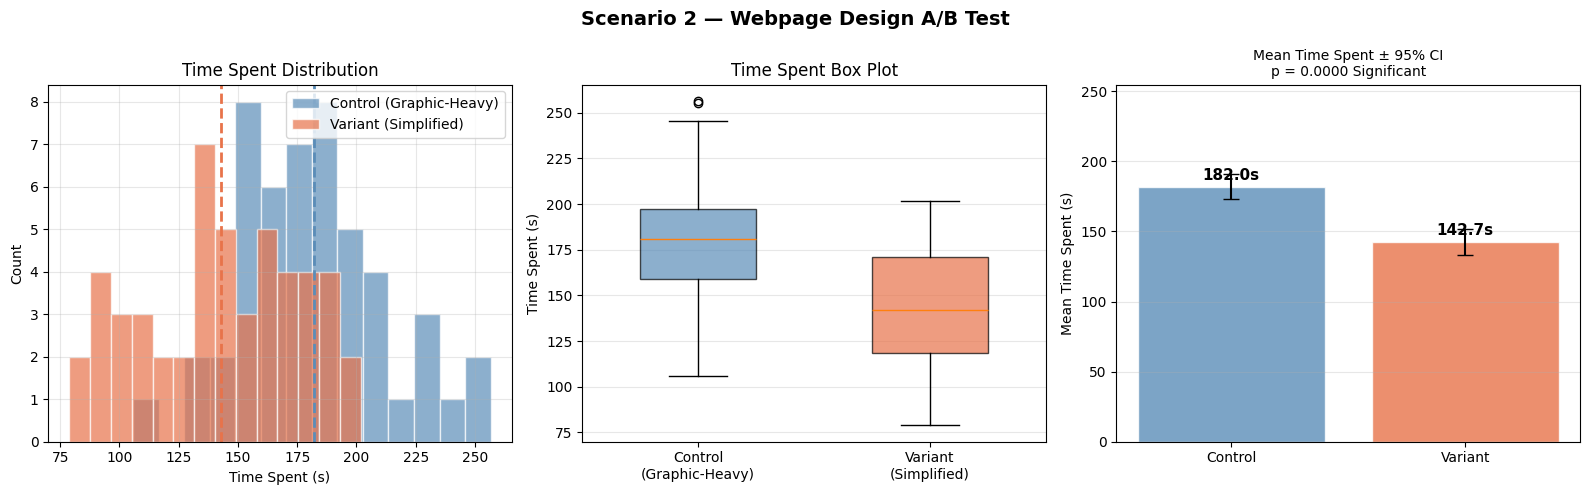

Plot saved ✓


In [13]:
# ── 12. YOUR CODE HERE — Step 3: Visualisations ───────────────────────────────
#
# Reproduce the 3-panel chart from Scenario 1 but for time_spent_s
# Panel 1: Histogram of both groups
# Panel 2: Box plot
# Panel 3: Mean ± 95% CI bar chart

# Write your code here:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Scenario 2 — Webpage Design A/B Test', fontsize=14, fontweight='bold')

colors = {'Control': '#5B8DB8', 'Variant': '#E8734A'}

# Plot 1: Histogram of time spent distributions
ax = axes[0]
ax.hist(wp_control, bins=14, alpha=0.7, color=colors['Control'], label='Control (Graphic-Heavy)', edgecolor='white')
ax.hist(wp_variant, bins=14, alpha=0.7, color=colors['Variant'], label='Variant (Simplified)', edgecolor='white')
ax.axvline(wp_control.mean(), color=colors['Control'], lw=2, ls='--')
ax.axvline(wp_variant.mean(), color=colors['Variant'], lw=2, ls='--')
ax.set_title('Time Spent Distribution'); ax.set_xlabel('Time Spent (s)'); ax.set_ylabel('Count')
ax.legend(); ax.grid(alpha=0.3)

# Plot 2: Box plot
ax2 = axes[1]
bp = ax2.boxplot([wp_control, wp_variant], labels=['Control\n(Graphic-Heavy)', 'Variant\n(Simplified)'],
                 patch_artist=True, widths=0.5, notch=False)
bp['boxes'][0].set_facecolor(colors['Control'])
bp['boxes'][1].set_facecolor(colors['Variant'])
for patch in bp['boxes']: patch.set_alpha(0.7)
ax2.set_title('Time Spent Box Plot'); ax2.set_ylabel('Time Spent (s)'); ax2.grid(alpha=0.3, axis='y')

# Plot 3: Mean time spent with 95% CI error bars
ax3 = axes[2]
means  = [wp_control.mean(), wp_variant.mean()]
errors = [stats.sem(wp_control) * t_crit, stats.sem(wp_variant) * t_crit]
bars = ax3.bar(['Control', 'Variant'], means, yerr=errors, capsize=6,
               color=[colors['Control'], colors['Variant']], alpha=0.8, edgecolor='white')
ax3.set_title('Mean Time Spent ± 95% CI'); ax3.set_ylabel('Mean Time Spent (s)')
ax3.set_ylim(0, max(means) * 1.4)
for bar, mean in zip(bars, means):
    ax3.text(bar.get_x() + bar.get_width()/2, mean + 5, f'{mean:.1f}s',
             ha='center', fontweight='bold', fontsize=11)
sig_label = f'p = {p_val:.4f} Significant' if p_val < ALPHA else f'p = {p_val:.4f} Not Significant'
ax3.set_title(f'Mean Time Spent ± 95% CI\n{sig_label}', fontsize=10)
ax3.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'ab_webpage_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✓')

In [14]:
# ── 13. YOUR CODE HERE — Step 4: Summary Table ────────────────────────────────
#
# Build a summary DataFrame like the one in Cell 8 for the webpage scenario
# Include: N, Mean, Std Dev, Std Error, Min, Max, t-stat, p-value, Decision

# Write your code here:

summary_wp = pd.DataFrame({
    'Metric':  ['N', 'Mean Time (s)', 'Std Dev', 'Std Error', 'Min Time (s)', 'Max Time (s)'],
    'Control (Graphic-Heavy)':  [
        len(wp_control),
        round(wp_control.mean(), 2),
        round(wp_control.std(), 2),
        round(stats.sem(wp_control), 2),
        round(wp_control.min(), 2),
        round(wp_control.max(), 2)
    ],
    'Variant (Simplified)': [
        len(wp_variant),
        round(wp_variant.mean(), 2),
        round(wp_variant.std(), 2),
        round(stats.sem(wp_variant), 2),
        round(wp_variant.min(), 2),
        round(wp_variant.max(), 2)
    ]
})

test_row = pd.DataFrame([{
    'Metric': '── Test Result ──',
    'Control (Graphic-Heavy)': f't = {t_stat:.4f}',
    'Variant (Simplified)': f'p = {p_val:.4f}'
}])
decision_row = pd.DataFrame([{
    'Metric': 'Decision',
    'Control (Graphic-Heavy)': 'Reject H₀' if p_val < ALPHA else 'Do not reject H₀',
    'Variant (Simplified)': 'Significant' if p_val < ALPHA else 'Not Significant'
}])
summary_wp = pd.concat([summary_wp, test_row, decision_row], ignore_index=True)

style_summary(summary_wp)

,Metric,Control (Graphic-Heavy),Variant (Simplified)
0,N,50.000000,50.000000
1,Mean Time (s),181.960000,142.690000
2,Std Dev,32.090000,33.210000
3,Std Error,4.540000,4.700000
4,Min Time (s),105.700000,78.800000
5,Max Time (s),256.600000,201.800000
6,── Test Result ──,t = -6.0127,p = 0.0000
7,Decision,Reject H₀,Significant


---
## Quick Reference — A/B Testing Cheat Sheet

| Term | Meaning |
|---|---|
| **Control (A)** | The existing / unchanged version |
| **Variant (B)** | The new / modified version |
| **CTR** | Clicks ÷ Impressions — how often users click |
| **p-value < 0.05** | Difference is statistically significant |
| **Cohen's d < 0.5** | Small effect size |
| **Cohen's d 0.5–0.8** | Medium effect size |
| **Cohen's d > 0.8** | Large effect size |
| **95% CI excludes 0** | Confirms significant difference |
| **Welch's t-test** | Used when group variances may differ (safer default) |

**Decision rule:** Reject H₀ if p-value < α (0.05). This means the observed difference is unlikely due to chance alone.